In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_churn.csv")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [6]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
(df["Churn Label"].value_counts(normalize=True) * 100).round(2)

Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64

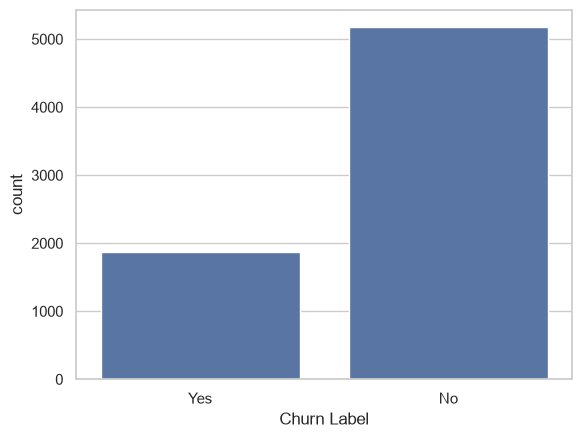

In [8]:
sns.countplot(data=df,x="Churn Label")
plt.show()

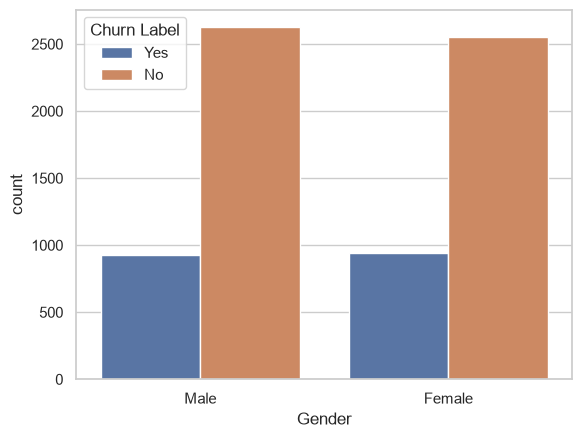

In [9]:
# Gender vs Churn Label
sns.countplot(data=df,
              x="Gender",
              hue="Churn Label")
plt.show()

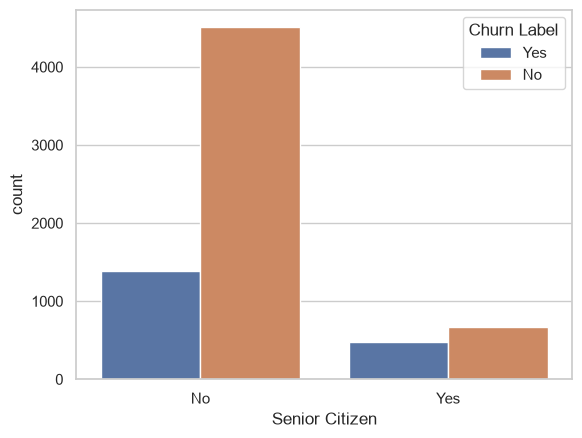

In [10]:
# Senior Citizen vs Churn Label
sns.countplot(data=df,
              x="Senior Citizen",
              hue="Churn Label")
plt.show()

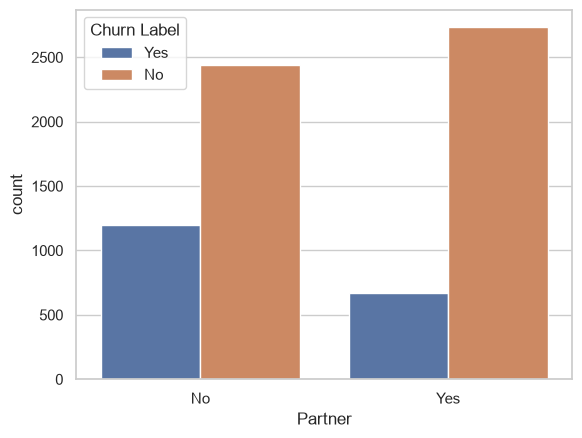

In [11]:
# partner vs Churn Label
sns.countplot(data=df,
              x="Partner",
              hue="Churn Label")
plt.show()

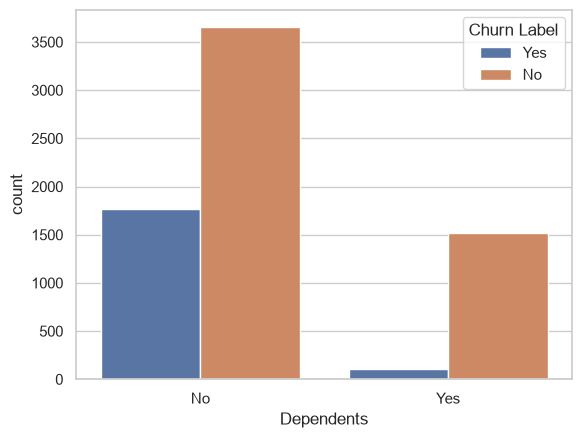

In [12]:
# Dependents vs Churn Label
sns.countplot(data=df,
              x="Dependents",
              hue="Churn Label")
plt.show()

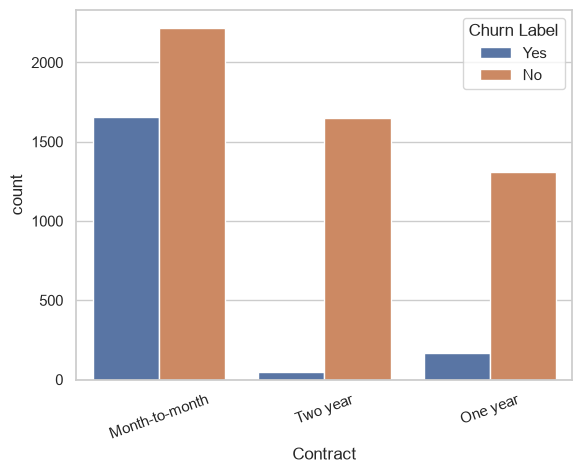

In [14]:
## Contract vs Churn Label
sns.countplot(data=df,
              x="Contract",
              hue="Churn Label")
plt.xticks(rotation=20)
plt.show()

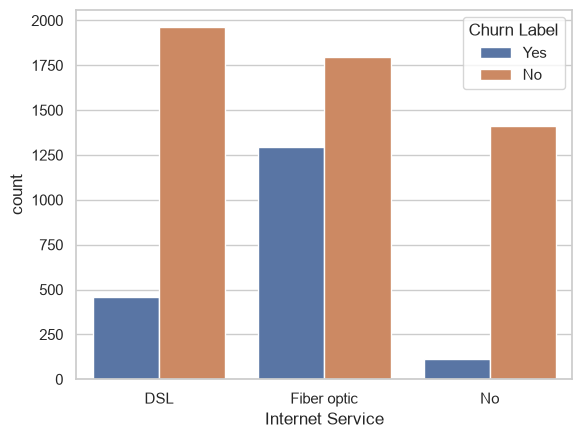

In [15]:
# internet service vs Churn Label
sns.countplot(data=df,
              x="Internet Service",
              hue="Churn Label")
plt.show()

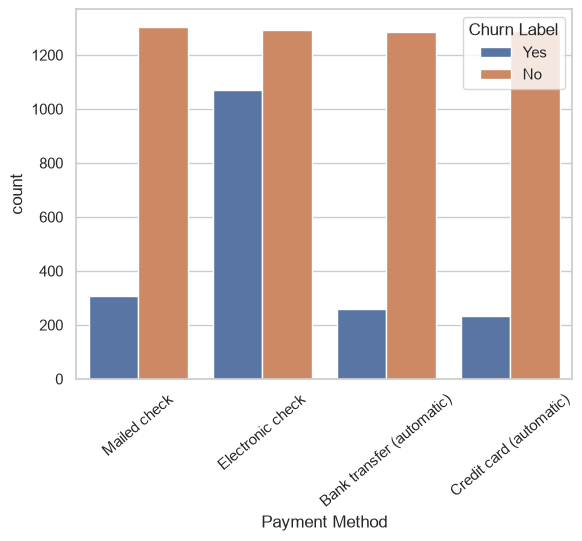

In [16]:
# payment method vs Churn Label
sns.countplot(data=df,
              x="Payment Method",
              hue="Churn Label")
plt.xticks(rotation=40)
plt.show()

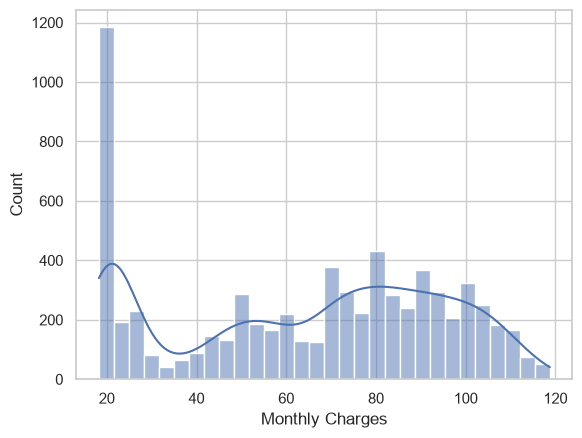

In [17]:
## Monthly charges distribution
sns.histplot(df["Monthly Charges"],
             bins=30,
             kde=True)
plt.show()

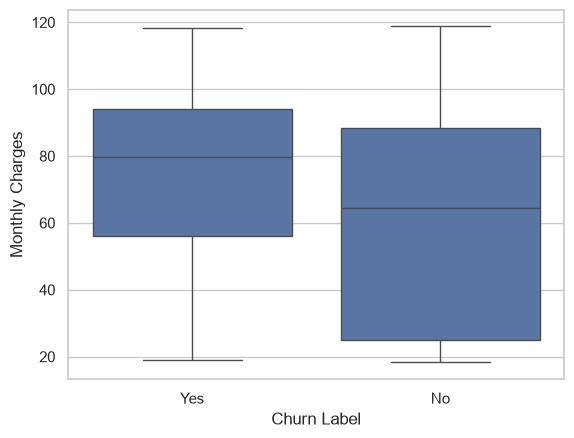

In [18]:
# Monthly charges vs Churn Label
sns.boxplot(data=df,
            x="Churn Label",
            y="Monthly Charges")
plt.show()

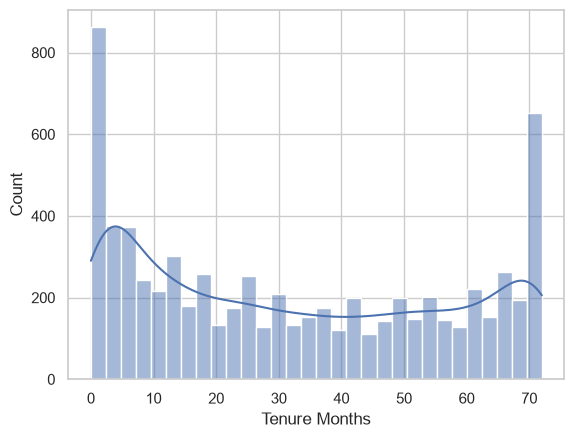

In [19]:
# Tenure distribution
sns.histplot(df["Tenure Months"],
             bins=30,
             kde=True)
plt.show()

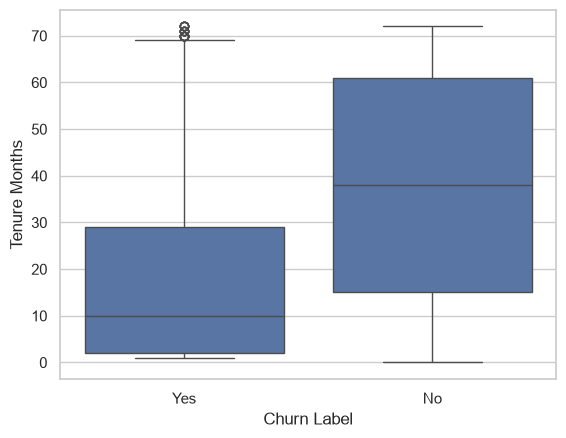

In [20]:
# tenure vs Churn Label
sns.boxplot(data=df,
            x="Churn Label",
            y="Tenure Months")
plt.show()

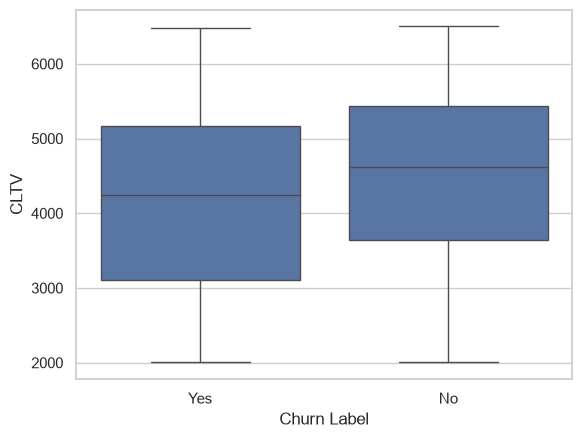

In [21]:
# customer lifetime value
sns.boxplot(data=df,
            x="Churn Label",
            y="CLTV")
plt.show()

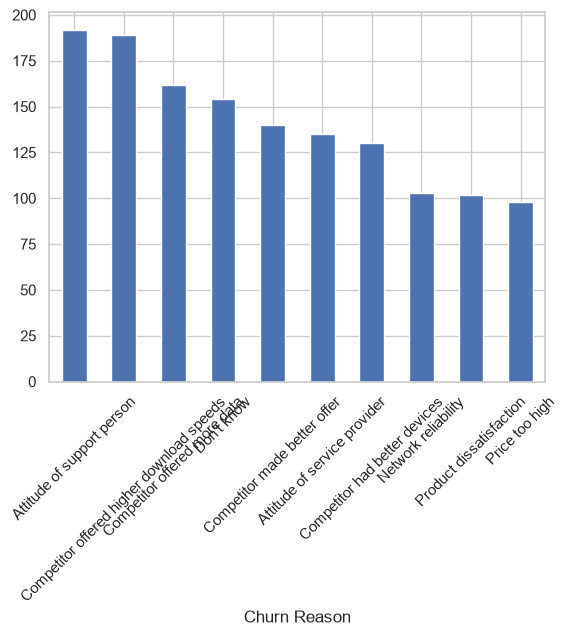

In [22]:
## top churn reasons
df["Churn Reason"].value_counts().head(10)

df["Churn Reason"].value_counts().head(10).plot(kind="bar")
plt.xticks(rotation=45)
plt.show()

In [23]:
# state wise churn 
pd.crosstab(df["State"],
            df["Churn Label"])

Churn Label,No,Yes
State,,
California,5174,1869


In [24]:
## city wise churn
df.groupby("City")["Churn Value"].mean().sort_values(ascending=False).head(10)

City
Fort Jones       1.0
Eldridge         1.0
Maricopa         1.0
Boulder Creek    1.0
Riverbank        1.0
Twain            1.0
Johannesburg     1.0
Smith River      1.0
Tipton           1.0
Wrightwood       1.0
Name: Churn Value, dtype: float64

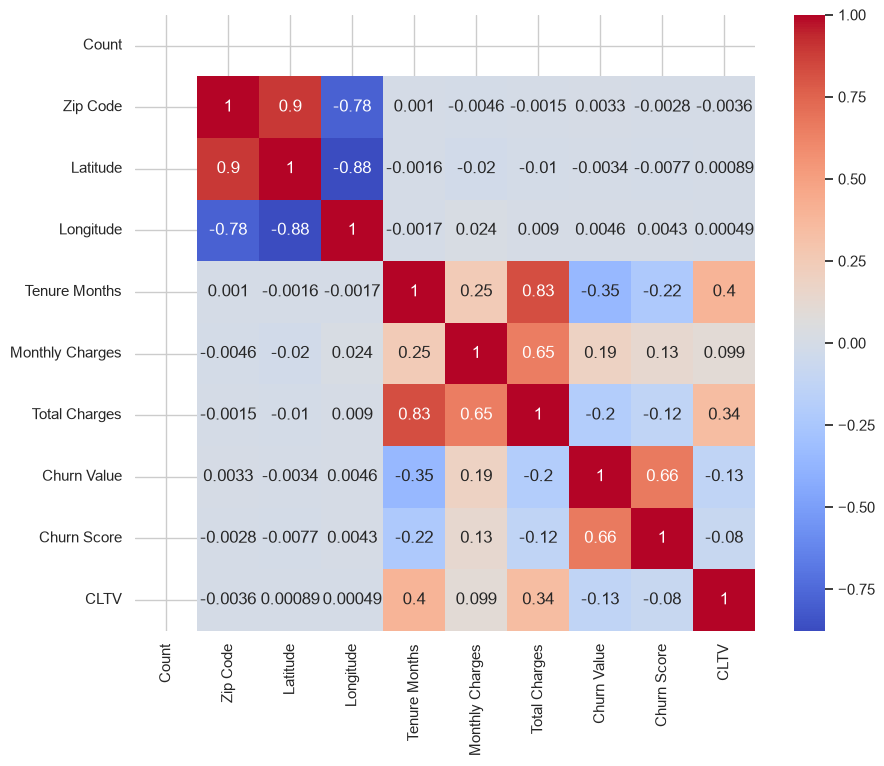

In [26]:
## correalation heatmap
numeric=df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")
plt.show()